In [2]:
import tensorflow as tf
import tempfile
import zipfile
import os
import h5py
import numpy as np
import glob
from numpy import linalg as LA
from scipy.stats import rankdata
from shutil import copyfile, move
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import keras
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten , InputLayer
from keras.layers import Conv2D, MaxPooling2D



import numpy as np
import pandas as pd

In [3]:
batch_size = 128
num_classes = 10
epochs = 10

# input image dimensions
img_rows, img_cols = 28, 28

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], img_rows * img_cols)
x_test = x_test.reshape(x_test.shape[0], img_rows * img_cols)
input_shape = (img_rows * img_cols, )

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# Convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 784)
60000 train samples
10000 test samples


In [4]:
# Reshape input data to 2D shape for CNN
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)

# Define the LeNet-5 model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(filters=6, kernel_size=(5, 5), activation='relu', input_shape=input_shape, padding='same'))

model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(tf.keras.layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(120, activation='relu'))
model.add(tf.keras.layers.Dense(84, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
logdir = tempfile.mkdtemp()
callbacks = [tf.keras.callbacks.TensorBoard(log_dir=logdir, profile_batch=0)]

model.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer='adam',
    metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=20
          )
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2346 - loss: 1.8672
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7576 - loss: 0.6429
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8168 - loss: 0.4684
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8424 - loss: 0.4152
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8727 - loss: 0.3599
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8837 - loss: 0.3253
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8908 - loss: 0.3044
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8992 - loss: 0.2847
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9032 - loss: 0.2703
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9077 - loss: 0.2577
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9057 - loss: 0.2555
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

In [15]:
#Save model
model_file = os.path.join(tempfile.mkdtemp(), "my_model.keras")
tf.keras.models.save_model(model, model_file, include_optimizer=False)

# Weight pruning

In [16]:
# Load original model
orig_model = tf.keras.models.load_model(model_file)

# Loop over different pruning levels
for k in [.25, .50, .60, .70, .80, .90, .95, .97, .99]:
    model = tf.keras.models.clone_model(orig_model)
    model.set_weights(orig_model.get_weights())

    pruned_weights = []
    for layer in model.layers:
        weights = layer.get_weights()
        if weights and len(weights[0].shape) > 1:  # Typically weights[0] is kernel, weights[1] is bias
            w = weights[0]
            ranks = (rankdata(np.abs(w), method='dense') - 1).astype(int).reshape(w.shape)
            lower_bound_rank = np.ceil(np.max(ranks) * k).astype(int)
            mask = (ranks > lower_bound_rank).astype(float)
            w_pruned = w * mask
            weights[0] = w_pruned
            layer.set_weights(weights)

    # Save the pruned model
    save_path = f"/tmp/weight_{k:.2f}.keras"
    model.save(save_path, include_optimizer=False)
    print(f"Saved pruned model with k={k} to {save_path}")

Saved pruned model with k=0.25 to /tmp/weight_0.25.keras
Saved pruned model with k=0.5 to /tmp/weight_0.50.keras
Saved pruned model with k=0.6 to /tmp/weight_0.60.keras
Saved pruned model with k=0.7 to /tmp/weight_0.70.keras
Saved pruned model with k=0.8 to /tmp/weight_0.80.keras
Saved pruned model with k=0.9 to /tmp/weight_0.90.keras
Saved pruned model with k=0.95 to /tmp/weight_0.95.keras
Saved pruned model with k=0.97 to /tmp/weight_0.97.keras
Saved pruned model with k=0.99 to /tmp/weight_0.99.keras


# Neuron pruning

In [17]:
# Load original model
orig_model = tf.keras.models.load_model(model_file)

# Iterate over pruning levels
for k in [.25, .50, .60, .70, .80, .90, .95, .97, .99]:
    # Clone the model and copy weights
    model = tf.keras.models.clone_model(orig_model)
    model.set_weights(orig_model.get_weights())

    for layer in model.layers:
        weights = layer.get_weights()
        if weights and len(weights[0].shape) == 2:  # Only dense layers
            w = weights[0]  # kernel shape: (input_dim, output_dim)
            norm = np.linalg.norm(w, axis=0)  # L2 norm of each neuron (column)
            norm = np.tile(norm, (w.shape[0], 1))  # shape: (input_dim, output_dim)

            # Rank and prune
            ranks = (rankdata(norm, method='dense') - 1).astype(int).reshape(norm.shape)
            lower_bound_rank = np.ceil(np.max(ranks) * k).astype(int)
            mask = (ranks > lower_bound_rank).astype(float)

            # Apply mask
            w_pruned = w * mask
            weights[0] = w_pruned
            layer.set_weights(weights)

    # Save pruned model
    save_path = f"/tmp/neuron_{k:.2f}.keras"
    model.save(save_path, include_optimizer=False)
    print(f"Saved pruned model at pruning ratio k={k} to: {save_path}")

Saved pruned model at pruning ratio k=0.25 to: /tmp/neuron_0.25.keras
Saved pruned model at pruning ratio k=0.5 to: /tmp/neuron_0.50.keras
Saved pruned model at pruning ratio k=0.6 to: /tmp/neuron_0.60.keras
Saved pruned model at pruning ratio k=0.7 to: /tmp/neuron_0.70.keras
Saved pruned model at pruning ratio k=0.8 to: /tmp/neuron_0.80.keras
Saved pruned model at pruning ratio k=0.9 to: /tmp/neuron_0.90.keras
Saved pruned model at pruning ratio k=0.95 to: /tmp/neuron_0.95.keras
Saved pruned model at pruning ratio k=0.97 to: /tmp/neuron_0.97.keras
Saved pruned model at pruning ratio k=0.99 to: /tmp/neuron_0.99.keras


In [18]:
# Collect pruned model file paths
files_weights = glob.glob('/tmp/weight_*.keras')
files_weights.sort()

files_neuron = glob.glob('/tmp/neuron_*.keras')
files_neuron.sort()

# Accuracy storage
accuracy_weights = []
accuracy_neurons = []

# Evaluate weight-pruned models
for f in files_weights:
    restored_model = tf.keras.models.load_model(f, compile=False)
    restored_model.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy'])
    score = restored_model.evaluate(x_test, y_test, verbose=0)
    accuracy_weights.append(score[1])
    print(f"Weight-pruned model ({f}): Accuracy = {score[1]:.4f}")

# Evaluate neuron-pruned models
for f in files_neuron:
    restored_model = tf.keras.models.load_model(f, compile=False)
    restored_model.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy'])
    score = restored_model.evaluate(x_test, y_test, verbose=0)
    accuracy_neurons.append(score[1])
    print(f"Neuron-pruned model ({f}): Accuracy = {score[1]:.4f}")


Weight-pruned model (/tmp/weight_0.25.keras): Accuracy = 0.8915
Weight-pruned model (/tmp/weight_0.50.keras): Accuracy = 0.5702
Weight-pruned model (/tmp/weight_0.60.keras): Accuracy = 0.5010
Weight-pruned model (/tmp/weight_0.70.keras): Accuracy = 0.2854
Weight-pruned model (/tmp/weight_0.80.keras): Accuracy = 0.1558
Weight-pruned model (/tmp/weight_0.90.keras): Accuracy = 0.1878
Weight-pruned model (/tmp/weight_0.95.keras): Accuracy = 0.1212
Weight-pruned model (/tmp/weight_0.97.keras): Accuracy = 0.0979
Weight-pruned model (/tmp/weight_0.99.keras): Accuracy = 0.1000
Neuron-pruned model (/tmp/neuron_0.25.keras): Accuracy = 0.4578
Neuron-pruned model (/tmp/neuron_0.50.keras): Accuracy = 0.2029
Neuron-pruned model (/tmp/neuron_0.60.keras): Accuracy = 0.1026
Neuron-pruned model (/tmp/neuron_0.70.keras): Accuracy = 0.1058
Neuron-pruned model (/tmp/neuron_0.80.keras): Accuracy = 0.1000
Neuron-pruned model (/tmp/neuron_0.90.keras): Accuracy = 0.1000
Neuron-pruned model (/tmp/neuron_0.95.ke

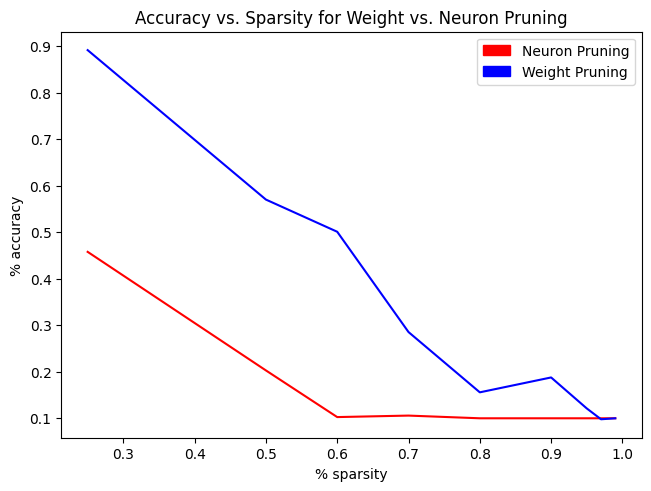

In [20]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.xlabel('% sparsity')
plt.ylabel('% accuracy')
plt.title('Accuracy vs. Sparsity for Weight vs. Neuron Pruning')
red_patch = mpatches.Patch(color='red', label='Neuron Pruning')
blue_patch = mpatches.Patch(color='blue',label='Weight Pruning')
plt.legend(handles=[red_patch,blue_patch],loc='upper right')
plt.plot([.25, .50, .60, .70, .80, .90, .95, .97, .99],accuracy_neurons,color='red')
plt.plot([.25, .50, .60, .70, .80, .90, .95, .97, .99],accuracy_weights,color='blue')
plt.show()

In [21]:
results = []

pruned_keras_files = files_neuron + files_weights
pruning_types = ['Neuron'] * len(files_neuron) + ['Weight'] * len(files_weights)
sparsity_levels = [0.25, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.97, 0.99] * 2

_, zip1 = tempfile.mkstemp('.zip')
with zipfile.ZipFile(zip1, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(model_file)

unpruned_size = os.path.getsize(model_file) / float(2**20)
unpruned_zip = os.path.getsize(zip1) / float(2**20)

print(f"Unpruned model size: {unpruned_size:.2f} MB → {unpruned_zip:.2f} MB (compressed)\n")

for i, pruned_file in enumerate(pruned_keras_files):
    _, zip_path = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(pruned_file)

    size_before = os.path.getsize(pruned_file) / float(2**20)
    size_after = os.path.getsize(zip_path) / float(2**20)

    results.append({
        "Pruning Type": pruning_types[i],
        "Sparsity": sparsity_levels[i],
        "Size Before Pruning(MB)": round(size_before, 2),
        "Size After Pruning (MB)": round(size_after, 2),
        "Compression Ratio": round(size_before / size_after, 2) if size_after > 0 else None
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

Unpruned model size: 0.75 MB → 0.33 MB (compressed)

Pruning Type  Sparsity  Size Before Pruning(MB)  Size After Pruning (MB)  Compression Ratio
      Neuron      0.25                     0.27                     0.10               2.63
      Neuron      0.50                     0.27                     0.08               3.32
      Neuron      0.60                     0.27                     0.07               3.76
      Neuron      0.70                     0.27                     0.06               4.32
      Neuron      0.80                     0.27                     0.05               5.16
      Neuron      0.90                     0.27                     0.04               6.48
      Neuron      0.95                     0.27                     0.03               7.66
      Neuron      0.97                     0.27                     0.03               8.23
      Neuron      0.99                     0.27                     0.03               8.93
      Weight      0.25     

In [22]:
model_grad_example = keras.Sequential()
model_grad_example.add(keras.layers.Dense(20, input_shape = (10, )))
model_grad_example.add(keras.layers.Dense(5))
model_grad_example.compile('adam', 'mse')

# Dummy data for the example model
dummy_in = np.ones((4, 10))
dummy_out = np.ones((4, 5))
# Initialize optimizer variables by running a train step
dummy_loss = model_grad_example.train_on_batch(dummy_in, dummy_out)

def get_weight_grad(model, inputs, outputs):
    """ Gets gradient of model for given inputs and outputs for all weights"""
    grads = model.optimizer.get_gradients(model.total_loss, model.trainable_weights)
    symb_inputs = (model._feed_inputs + model._feed_targets + model._feed_sample_weights)
    f = K.function(symb_inputs, grads)
    x, y, sample_weight = model._standardize_user_data(inputs, outputs)
    output_grad = f(x + y + sample_weight)
    return output_grad

def get_layer_output_grad(model, inputs, outputs, layer=-1):
    """ Gets gradient of a layer output for given inputs and outputs"""
    grads = model.optimizer.get_gradients(model.total_loss, model.layers[layer].output)
    symb_inputs = (model._feed_inputs + model._feed_targets + model._feed_sample_weights)
    f = K.function(symb_inputs, grads)
    x, y, sample_weight = model._standardize_user_data(inputs, outputs)
    output_grad = f(x + y + sample_weight)
    return output_grad

pruning_ratios = [.25, .50, .60, .70, .80, .90, .95, .97, .99] # Renamed from 'k' to avoid conflict if k=Keras backend

print("\nStarting LeNet-5 Weight Pruning...")
for k_prune_ratio in pruning_ratios:
    model_being_pruned = tf.keras.models.clone_model(orig_model)
    model_being_pruned.set_weights(orig_model.get_weights())
    model_being_pruned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    pruned_weights_collector = []

    for layer in model_being_pruned.layers:
        current_layer_weights = layer.get_weights()
        if current_layer_weights and len(current_layer_weights) > 0 and len(current_layer_weights[0].shape) > 1:
            w = current_layer_weights[0] # The kernel

            if w.size == 0:
                continue

            # Calculate ranks based on absolute magnitude
            ranks = (rankdata(np.abs(w), method='dense') - 1).astype(int).reshape(w.shape)

            lower_bound_rank = np.ceil(np.max(ranks) * k_prune_ratio).astype(int)

            # Create a mask for weights to keep (those with rank > lower_bound_rank)
            mask = (ranks > lower_bound_rank).astype(float)

            w_pruned = w * mask # Apply pruning

            current_layer_weights[0] = w_pruned
            layer.set_weights(current_layer_weights)


    # Save the pruned model
    save_path = f"/tmp/weight_{k_prune_ratio:.2f}.keras"
    model_being_pruned.save(save_path, include_optimizer=False)
    print(f"Saved pruned model with k={k_prune_ratio} to {save_path}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting LeNet-5 Weight Pruning...
Saved pruned model with k=0.25 to /tmp/weight_0.25.keras
Saved pruned model with k=0.5 to /tmp/weight_0.50.keras
Saved pruned model with k=0.6 to /tmp/weight_0.60.keras
Saved pruned model with k=0.7 to /tmp/weight_0.70.keras
Saved pruned model with k=0.8 to /tmp/weight_0.80.keras
Saved pruned model with k=0.9 to /tmp/weight_0.90.keras
Saved pruned model with k=0.95 to /tmp/weight_0.95.keras
Saved pruned model with k=0.97 to /tmp/weight_0.97.keras
Saved pruned model with k=0.99 to /tmp/weight_0.99.keras
